In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Imports successful")

Imports successful


In [2]:
df = pd.read_csv("../data/raw/Titanic dataset.csv")
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [3]:
print("Shape:", df.shape)

Shape: (1309, 14)


In [4]:
print("Column names:")
print(df.columns.tolist())

Column names:
['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest']


In [5]:
print("Data types:")
print(df.dtypes)

Data types:
pclass         int64
survived       int64
name             str
sex              str
age          float64
sibsp          int64
parch          int64
ticket           str
fare         float64
cabin            str
embarked         str
boat             str
body         float64
home.dest        str
dtype: object


In [6]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64


In [7]:
print("Unique values:")
print(df.nunique())

Unique values:
pclass          3
survived        2
name         1307
sex             2
age            98
sibsp           7
parch           8
ticket        929
fare          281
cabin         186
embarked        3
boat           27
body          121
home.dest     369
dtype: int64


## Dataset Information

Dataset: Titanic Dataset

Source: Kaggle – Titanic: Machine Learning from Disaster  
Source URL: https://www.kaggle.com/datasets/sakshisatre/titanic-dataset

License: The dataset is provided by Kaggle for use in the Titanic competition and is publicly available for educational and analytical purposes.

Why I chose this dataset:
I chose the Titanic dataset because it contains both numerical and categorical variables and has enough rows to practice data cleaning, grouping, feature engineering, NumPy computations, and visualization. It is also a well-known dataset, which makes it easier to understand the meaning of the variables and focus on learning the data analysis process.

## Task 2 : Data Cleaning 

In [8]:
df.isnull().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

In [9]:
df.dtypes

pclass         int64
survived       int64
name             str
sex              str
age          float64
sibsp          int64
parch          int64
ticket           str
fare         float64
cabin            str
embarked         str
boat             str
body         float64
home.dest        str
dtype: object

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df[df.isnull().any(axis=1)].head() #lets us see actual rows containing missing values.

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [12]:
# Fill missing Age values with the median because Age is numeric
# and the median is less affected by unusually high or low ages.
df["age"] = df["age"].fillna(df["age"].median())

# Fill the missing Fare value with the median because Fare is numeric
# and only one value is missing.
df["fare"] = df["fare"].fillna(df["fare"].median())

# Fill missing Embarked values with the most common category (mode)
# because only two values are missing.
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Create a Cabin missing-value indicator because Cabin has many
# missing values, and the fact that a cabin is unknown may itself be useful.
df["cabin_missing"] = df["cabin"].isna().astype(int)

# No duplicate rows were found, so no rows were removed.

print("Cleaning completed.")

Cleaning completed.


In [13]:
df.isnull().sum()

pclass              0
survived            0
name                0
sex                 0
age                 0
sibsp               0
parch               0
ticket              0
fare                0
cabin            1014
embarked            0
boat              823
body             1188
home.dest         564
cabin_missing       0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.dtypes

pclass             int64
survived           int64
name                 str
sex                  str
age              float64
sibsp              int64
parch              int64
ticket               str
fare             float64
cabin                str
embarked             str
boat                 str
body             float64
home.dest            str
cabin_missing      int64
dtype: object

## Task 3 : GroupBy and Merge 

In [16]:
print("Shape before GroupBy:", df.shape)

Shape before GroupBy: (1309, 15)


In [17]:
class_stats = df.groupby("pclass").agg(
    survival_rate=("survived", "mean"),
    average_fare=("fare", "mean")
).reset_index()

class_stats

,pclass,survival_rate,average_fare
0,1,0.619195,87.508992
1,2,0.429603,21.179196
2,3,0.255289,13.304513


In [18]:
# Merge class-level statistics back onto each passenger
# so every passenger can be compared with the average of their class.
df = df.merge(class_stats, on="pclass", how="left")

print("Shape after GroupBy + Merge:", df.shape)

Shape after GroupBy + Merge: (1309, 17)


In [19]:
print("Shape before Pivot:", df.shape)

Shape before Pivot: (1309, 17)


In [20]:
# Pivoting survival counts by passenger class makes it easier to compare survival patterns across classes.
survival_pivot = df.pivot_table(
    index="pclass",
    columns="survived",
    values="name",
    aggfunc="count",
    fill_value=0
)

survival_pivot

survived,0,1
pclass,,
1,123,200
2,158,119
3,528,181


In [21]:
print("Shape before Pivot:", df.shape)

Shape before Pivot: (1309, 17)


## Task 4: NumPy-Based Computation 

In [22]:
fare_array = df["fare"].to_numpy()
print(fare_array[:10])

[211.3375 151.55   151.55   151.55   151.55    26.55    77.9583   0.
  51.4792  49.5042]


In [23]:
fare_mean = np.mean(fare_array)
fare_std = np.std(fare_array)

fare_standardized = (fare_array - fare_mean) / fare_std

In [24]:
print("Mean:", np.mean(fare_standardized))
print("Standard deviation:", np.std(fare_standardized))
print("Minimum:", np.min(fare_standardized))
print("Maximum:", np.max(fare_standardized))

Mean: 4.34250717042078e-17
Standard deviation: 0.9999999999999999
Minimum: -0.6434642498641783
Maximum: 9.262027654708204


In [25]:
df["fare"].isnull().sum()

np.int64(0)

In [26]:
df["fare_standardized"] = fare_standardized

In [27]:
df[["fare", "fare_standardized"]].head()

,fare,fare_standardized
0,211.3375,3.442584
1,151.5500,2.286639
2,151.5500,2.286639
3,151.5500,2.286639
4,151.5500,2.286639


## Task 5: Exploratory Visualization

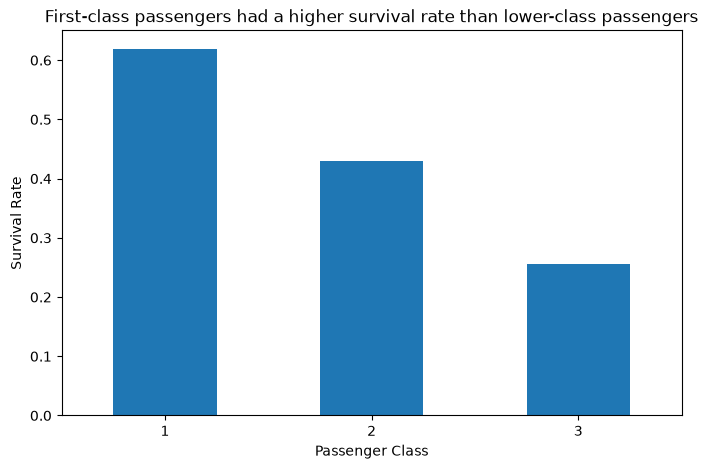

In [28]:
# Calculate survival rate for each passenger class
survival_by_class = df.groupby("pclass")["survived"].mean()

plt.figure(figsize=(8, 5))

survival_by_class.plot(kind="bar")

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.title("First-class passengers had a higher survival rate than lower-class passengers")

plt.xticks(rotation=0)

plt.savefig("../reports/a2_chart1.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

In [30]:
survival_by_age = df.groupby(
    "age_group", observed=True
)["survived"].mean()

print(survival_by_age)

age_group
Child          0.574468
Teen           0.414141
Young Adult    0.350126
Adult          0.411765
Senior         0.242424
Name: survived, dtype: float64


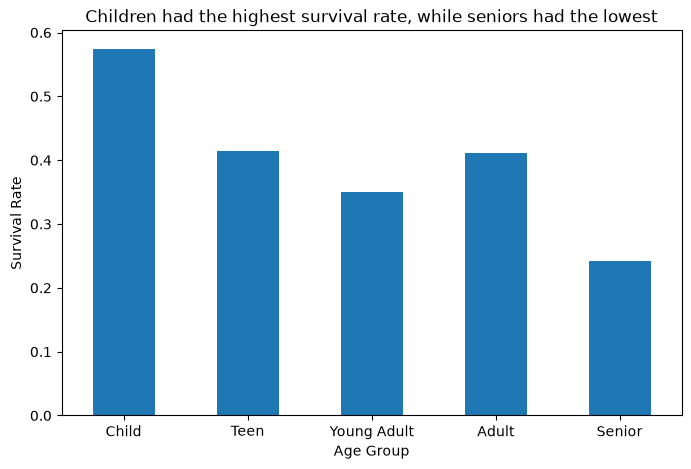

In [31]:
plt.figure(figsize=(8, 5))

survival_by_age.plot(kind="bar")

plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.title("Children had the highest survival rate, while seniors had the lowest")

plt.xticks(rotation=0)

plt.savefig("../reports/a2_chart2.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 6 : Cleaned Dataset and Report 

In [32]:
df.columns

Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest',
       'cabin_missing', 'survival_rate', 'average_fare', 'fare_standardized',
       'age_group'],
      dtype='str')

In [33]:
df.shape

(1309, 19)

In [34]:
df.to_csv("../data/processed/titanic_cleaned.csv", index=False)

In [35]:
import os

os.listdir("../data/processed")

['.gitkeep', 'titanic_cleaned.csv']

In [36]:
df.columns

Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest',
       'cabin_missing', 'survival_rate', 'average_fare', 'fare_standardized',
       'age_group'],
      dtype='str')

In [37]:
df.shape

(1309, 19)

In [38]:
cleaned_df = pd.read_csv("../data/processed/titanic_cleaned.csv")

print(cleaned_df.shape)
print(cleaned_df.head())

(1309, 19)
   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

     age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.00      0      0   24160  211.3375       B5        S    2    NaN   
1   0.92      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.00      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.00      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4  25.00      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest  cabin_missing  survival_rat

In [39]:
print("Final dataframe shape:", df.shape)
print("Number of columns:", len(df.columns))
print("Missing values:")
print(df.isnull().sum().sum())

Final dataframe shape: (1309, 19)
Number of columns: 19
Missing values:
3589


In [40]:
print(df.isnull().sum()[df.isnull().sum() > 0])

cabin        1014
boat          823
body         1188
home.dest     564
dtype: int64


In [43]:
import os

print("Processed dataset exists:",
      os.path.exists("../data/processed/titanic_cleaned.csv"))

print("Chart 1 exists:",
      os.path.exists("../reports/a2_chart1.png"))

print("Chart 2 exists:",
      os.path.exists("../reports/a2_chart2.png"))

print("Report exists:",
      os.path.exists("../reports/weekend-a2-report.md"))

Processed dataset exists: True
Chart 1 exists: True
Chart 2 exists: True
Report exists: True
